# Cleanning - Candy data

### Dataset Description 

- Internal_ID
- Q1-Going Out?: Are you actually going trick or treating yourself? "has values `Yes or No`"
- Q2-Gender: It has four different options, `Femal ,Male ,Other ,I'd rather not say`
- Q3-Age: Numerical field
- Q4-Country: Text Field, but users have written their own version of the names. Example, for America, there are entries such as USA, us, US, America so we should consider that while cleanning
- Q5-State/Province: Text Field, but users have written their own version of the names. Same as the country data.
- Q6-Joy Or Despair: All kinds of chocolate bars are the questions with three distinct options to choose from (Joy, Meh, Despair).
- Q7-Joy Other: Text Field to write items not included above that give you JOY. Lots of missing values.
- Q8-Despair Other: Text Field ti write items not included above that give you DESPAIR. Lots of missing values.
- Q9-Other Comments: Text Field. Lots of missing values.
- Q10-Dress: Binary field. Missing values present
- Unnamed: 113
- Q11-Day: Binary Answer Field. Missing values present


# 1- import packages and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from fuzzywuzzy import process

In [2]:
df=pd.read_excel('candyhierarchy2017.xlsx')

# 2- show some general properties for the data 

In [3]:
df.head(9)

,Internal ID,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6 | 100 Grand Bar,Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6 | Any full-sized candy bar,Q6 | Black Jacks,...,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,Q12: MEDIA [Daily Dish],Q12: MEDIA [Science],Q12: MEDIA [ESPN],Q12: MEDIA [Yahoo],"Click Coordinates (x, y)"
0,90258773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,90272821,No,Male,44,USA,NM,MEH,DESPAIR,JOY,MEH,...,NaN,Bottom line is Twix is really the only candy w...,White and gold,NaN,Sunday,NaN,1.0,NaN,NaN,"(84, 25)"
2,90272829,NaN,Male,49,USA,Virginia,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,90272840,No,Male,40,us,or,MEH,DESPAIR,JOY,MEH,...,NaN,Raisins can go to hell,White and gold,NaN,Sunday,NaN,1.0,NaN,NaN,"(75, 23)"
4,90272841,No,Male,23,usa,exton pa,JOY,DESPAIR,JOY,DESPAIR,...,NaN,NaN,White and gold,NaN,Friday,NaN,1.0,NaN,NaN,"(70, 10)"
5,90272852,No,Male,NaN,NaN,NaN,JOY,DESPAIR,JOY,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,"(75, 23)"
6,90272853,No,Male,53,usa,Colorado,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,90272854,No,Male,33,canada,ontario,JOY,DESPAIR,JOY,DESPAIR,...,when the little kids get the big chocolate bar...,"first person to give out cans of beer, wins",Blue and black,NaN,Friday,NaN,1.0,NaN,NaN,"(55, 5)"
8,90272858,No,Male,40,Canada,Ontario,JOY,DESPAIR,JOY,MEH,...,NaN,NaN,Blue and black,NaN,Sunday,NaN,1.0,NaN,NaN,"(76, 24)"


In [4]:
pd.set_option("display.max_columns",None)

In [5]:
df.head()

,Internal ID,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6 | 100 Grand Bar,Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6 | Any full-sized candy bar,Q6 | Black Jacks,Q6 | Bonkers (the candy),Q6 | Bonkers (the board game),Q6 | Bottle Caps,Q6 | Box'o'Raisins,Q6 | Broken glow stick,Q6 | Butterfinger,Q6 | Cadbury Creme Eggs,Q6 | Candy Corn,Q6 | Candy that is clearly just the stuff given out for free at restaurants,Q6 | Caramellos,"Q6 | Cash, or other forms of legal tender",Q6 | Chardonnay,Q6 | Chick-o-Sticks (we donÕt know what that is),Q6 | Chiclets,Q6 | Coffee Crisp,Q6 | Creepy Religious comics/Chick Tracts,Q6 | Dental paraphenalia,Q6 | Dots,Q6 | Dove Bars,Q6 | Fuzzy Peaches,Q6 | Generic Brand Acetaminophen,Q6 | Glow sticks,Q6 | Goo Goo Clusters,Q6 | Good N' Plenty,Q6 | Gum from baseball cards,Q6 | Gummy Bears straight up,Q6 | Hard Candy,Q6 | Healthy Fruit,Q6 | Heath Bar,Q6 | Hershey's Dark Chocolate,Q6 | HersheyÕs Milk Chocolate,Q6 | Hershey's Kisses,Q6 | Hugs (actual physical hugs),Q6 | Jolly Rancher (bad flavor),Q6 | Jolly Ranchers (good flavor),Q6 | JoyJoy (Mit Iodine!),Q6 | Junior Mints,Q6 | Senior Mints,Q6 | Kale smoothie,Q6 | Kinder Happy Hippo,Q6 | Kit Kat,Q6 | LaffyTaffy,Q6 | LemonHeads,Q6 | Licorice (not black),Q6 | Licorice (yes black),Q6 | Lindt Truffle,Q6 | Lollipops,Q6 | Mars,Q6 | Maynards,Q6 | Mike and Ike,Q6 | Milk Duds,Q6 | Milky Way,Q6 | Regular M&Ms,Q6 | Peanut M&MÕs,Q6 | Blue M&M's,Q6 | Red M&M's,Q6 | Green Party M&M's,Q6 | Independent M&M's,Q6 | Abstained from M&M'ing.,Q6 | Minibags of chips,Q6 | Mint Kisses,Q6 | Mint Juleps,Q6 | Mr. Goodbar,Q6 | Necco Wafers,Q6 | Nerds,Q6 | Nestle Crunch,Q6 | Now'n'Laters,Q6 | Peeps,Q6 | Pencils,Q6 | Pixy Stix,Q6 | Real Housewives of Orange County Season 9 Blue-Ray,Q6 | ReeseÕs Peanut Butter Cups,Q6 | Reese's Pieces,Q6 | Reggie Jackson Bar,Q6 | Rolos,Q6 | Sandwich-sized bags filled with BooBerry Crunch,Q6 | Skittles,Q6 | Smarties (American),Q6 | Smarties (Commonwealth),Q6 | Snickers,Q6 | Sourpatch Kids (i.e. abominations of nature),Q6 | Spotted Dick,Q6 | Starburst,Q6 | Sweet Tarts,Q6 | Swedish Fish,Q6 | Sweetums (a friend to diabetes),Q6 | Take 5,Q6 | Tic Tacs,Q6 | Those odd marshmallow circus peanut things,Q6 | Three Musketeers,Q6 | Tolberone something or other,Q6 | Trail Mix,Q6 | Twix,"Q6 | Vials of pure high fructose corn syrup, for main-lining into your vein",Q6 | Vicodin,Q6 | Whatchamacallit Bars,Q6 | White Bread,Q6 | Whole Wheat anything,Q6 | York Peppermint Patties,Q7: JOY OTHER,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,Q12: MEDIA [Daily Dish],Q12: MEDIA [Science],Q12: MEDIA [ESPN],Q12: MEDIA [Yahoo],"Click Coordinates (x, y)"
0,90258773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,90272821,No,Male,44,USA,NM,MEH,DESPAIR,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,JOY,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,MEH,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,JOY,JOY,MEH,JOY,JOY,JOY,JOY,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,Mounds,NaN,Bottom line is Twix is really the only candy w...,White and gold,NaN,Sunday,Na

In [6]:
df.shape

(2460, 120)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Columns: 120 entries, Internal ID to Click Coordinates (x, y)
dtypes: float64(4), int64(1), object(115)
memory usage: 2.3+ MB


In [8]:
df.info(verbose=True,null_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 120 columns):
 #    Column                                                                                 Non-Null Count  Dtype  
---   ------                                                                                 --------------  -----  
 0    Internal ID                                                                            2460 non-null   int64  
 1    Q1: GOING OUT?                                                                         2350 non-null   object 
 2    Q2: GENDER                                                                             2419 non-null   object 
 3    Q3: AGE                                                                                2376 non-null   object 
 4    Q4: COUNTRY                                                                            2396 non-null   object 
 5    Q5: STATE, PROVINCE, COUNTY, ETC                                   

/tmp/ipykernel_25394/2728897127.py:1: FutureWarning: null_counts is deprecated. Use show_counts instead
  df.info(verbose=True,null_counts=True)


In [9]:
df.dtypes.to_frame().T

,Internal ID,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6 | 100 Grand Bar,Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6 | Any full-sized candy bar,Q6 | Black Jacks,Q6 | Bonkers (the candy),Q6 | Bonkers (the board game),Q6 | Bottle Caps,Q6 | Box'o'Raisins,Q6 | Broken glow stick,Q6 | Butterfinger,Q6 | Cadbury Creme Eggs,Q6 | Candy Corn,Q6 | Candy that is clearly just the stuff given out for free at restaurants,Q6 | Caramellos,"Q6 | Cash, or other forms of legal tender",Q6 | Chardonnay,Q6 | Chick-o-Sticks (we donÕt know what that is),Q6 | Chiclets,Q6 | Coffee Crisp,Q6 | Creepy Religious comics/Chick Tracts,Q6 | Dental paraphenalia,Q6 | Dots,Q6 | Dove Bars,Q6 | Fuzzy Peaches,Q6 | Generic Brand Acetaminophen,Q6 | Glow sticks,Q6 | Goo Goo Clusters,Q6 | Good N' Plenty,Q6 | Gum from baseball cards,Q6 | Gummy Bears straight up,Q6 | Hard Candy,Q6 | Healthy Fruit,Q6 | Heath Bar,Q6 | Hershey's Dark Chocolate,Q6 | HersheyÕs Milk Chocolate,Q6 | Hershey's Kisses,Q6 | Hugs (actual physical hugs),Q6 | Jolly Rancher (bad flavor),Q6 | Jolly Ranchers (good flavor),Q6 | JoyJoy (Mit Iodine!),Q6 | Junior Mints,Q6 | Senior Mints,Q6 | Kale smoothie,Q6 | Kinder Happy Hippo,Q6 | Kit Kat,Q6 | LaffyTaffy,Q6 | LemonHeads,Q6 | Licorice (not black),Q6 | Licorice (yes black),Q6 | Lindt Truffle,Q6 | Lollipops,Q6 | Mars,Q6 | Maynards,Q6 | Mike and Ike,Q6 | Milk Duds,Q6 | Milky Way,Q6 | Regular M&Ms,Q6 | Peanut M&MÕs,Q6 | Blue M&M's,Q6 | Red M&M's,Q6 | Green Party M&M's,Q6 | Independent M&M's,Q6 | Abstained from M&M'ing.,Q6 | Minibags of chips,Q6 | Mint Kisses,Q6 | Mint Juleps,Q6 | Mr. Goodbar,Q6 | Necco Wafers,Q6 | Nerds,Q6 | Nestle Crunch,Q6 | Now'n'Laters,Q6 | Peeps,Q6 | Pencils,Q6 | Pixy Stix,Q6 | Real Housewives of Orange County Season 9 Blue-Ray,Q6 | ReeseÕs Peanut Butter Cups,Q6 | Reese's Pieces,Q6 | Reggie Jackson Bar,Q6 | Rolos,Q6 | Sandwich-sized bags filled with BooBerry Crunch,Q6 | Skittles,Q6 | Smarties (American),Q6 | Smarties (Commonwealth),Q6 | Snickers,Q6 | Sourpatch Kids (i.e. abominations of nature),Q6 | Spotted Dick,Q6 | Starburst,Q6 | Sweet Tarts,Q6 | Swedish Fish,Q6 | Sweetums (a friend to diabetes),Q6 | Take 5,Q6 | Tic Tacs,Q6 | Those odd marshmallow circus peanut things,Q6 | Three Musketeers,Q6 | Tolberone something or other,Q6 | Trail Mix,Q6 | Twix,"Q6 | Vials of pure high fructose corn syrup, for main-lining into your vein",Q6 | Vicodin,Q6 | Whatchamacallit Bars,Q6 | White Bread,Q6 | Whole Wheat anything,Q6 | York Peppermint Patties,Q7: JOY OTHER,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,Q12: MEDIA [Daily Dish],Q12: MEDIA [Science],Q12: MEDIA [ESPN],Q12: MEDIA [Yahoo],"Click Coordinates (x, y)"
0,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,object


In [10]:
df.describe()

,Internal ID,Q12: MEDIA [Daily Dish],Q12: MEDIA [Science],Q12: MEDIA [ESPN],Q12: MEDIA [Yahoo]
count,2.460000e+03,85.0,1362.0,99.0,67.0
mean,9.028016e+07,1.0,1.0,1.0,1.0
std,7.435532e+03,0.0,0.0,0.0,0.0
min,9.025877e+07,1.0,1.0,1.0,1.0
25%,9.027520e+07,1.0,1.0,1.0,1.0
50%,9.027780e+07,1.0,1.0,1.0,1.0
75%,9.028242e+07,1.0,1.0,1.0,1.0
max,9.031480e+07,1.0,1.0,1.0,1.0


In [11]:
df.describe(include=["O"])

,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6 | 100 Grand Bar,Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6 | Any full-sized candy bar,Q6 | Black Jacks,Q6 | Bonkers (the candy),Q6 | Bonkers (the board game),Q6 | Bottle Caps,Q6 | Box'o'Raisins,Q6 | Broken glow stick,Q6 | Butterfinger,Q6 | Cadbury Creme Eggs,Q6 | Candy Corn,Q6 | Candy that is clearly just the stuff given out for free at restaurants,Q6 | Caramellos,"Q6 | Cash, or other forms of legal tender",Q6 | Chardonnay,Q6 | Chick-o-Sticks (we donÕt know what that is),Q6 | Chiclets,Q6 | Coffee Crisp,Q6 | Creepy Religious comics/Chick Tracts,Q6 | Dental paraphenalia,Q6 | Dots,Q6 | Dove Bars,Q6 | Fuzzy Peaches,Q6 | Generic Brand Acetaminophen,Q6 | Glow sticks,Q6 | Goo Goo Clusters,Q6 | Good N' Plenty,Q6 | Gum from baseball cards,Q6 | Gummy Bears straight up,Q6 | Hard Candy,Q6 | Healthy Fruit,Q6 | Heath Bar,Q6 | Hershey's Dark Chocolate,Q6 | HersheyÕs Milk Chocolate,Q6 | Hershey's Kisses,Q6 | Hugs (actual physical hugs),Q6 | Jolly Rancher (bad flavor),Q6 | Jolly Ranchers (good flavor),Q6 | JoyJoy (Mit Iodine!),Q6 | Junior Mints,Q6 | Senior Mints,Q6 | Kale smoothie,Q6 | Kinder Happy Hippo,Q6 | Kit Kat,Q6 | LaffyTaffy,Q6 | LemonHeads,Q6 | Licorice (not black),Q6 | Licorice (yes black),Q6 | Lindt Truffle,Q6 | Lollipops,Q6 | Mars,Q6 | Maynards,Q6 | Mike and Ike,Q6 | Milk Duds,Q6 | Milky Way,Q6 | Regular M&Ms,Q6 | Peanut M&MÕs,Q6 | Blue M&M's,Q6 | Red M&M's,Q6 | Green Party M&M's,Q6 | Independent M&M's,Q6 | Abstained from M&M'ing.,Q6 | Minibags of chips,Q6 | Mint Kisses,Q6 | Mint Juleps,Q6 | Mr. Goodbar,Q6 | Necco Wafers,Q6 | Nerds,Q6 | Nestle Crunch,Q6 | Now'n'Laters,Q6 | Peeps,Q6 | Pencils,Q6 | Pixy Stix,Q6 | Real Housewives of Orange County Season 9 Blue-Ray,Q6 | ReeseÕs Peanut Butter Cups,Q6 | Reese's Pieces,Q6 | Reggie Jackson Bar,Q6 | Rolos,Q6 | Sandwich-sized bags filled with BooBerry Crunch,Q6 | Skittles,Q6 | Smarties (American),Q6 | Smarties (Commonwealth),Q6 | Snickers,Q6 | Sourpatch Kids (i.e. abominations of nature),Q6 | Spotted Dick,Q6 | Starburst,Q6 | Sweet Tarts,Q6 | Swedish Fish,Q6 | Sweetums (a friend to diabetes),Q6 | Take 5,Q6 | Tic Tacs,Q6 | Those odd marshmallow circus peanut things,Q6 | Three Musketeers,Q6 | Tolberone something or other,Q6 | Trail Mix,Q6 | Twix,"Q6 | Vials of pure high fructose corn syrup, for main-lining into your vein",Q6 | Vicodin,Q6 | Whatchamacallit Bars,Q6 | White Bread,Q6 | Whole Wheat anything,Q6 | York Peppermint Patties,Q7: JOY OTHER,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,"Click Coordinates (x, y)"
count,2350,2419,2376,2396,2360,1713,1726,1788,1502,1468,1454,1695,1772,1754,1778,1777,1782,1769,1708,1780,1717,1514,1749,1607,1756,1768,1731,1758,1637,1729,1763,1581,1726,1744,1763,1765,1766,1748,1787,1788,1782,1747,1766,1765,1434,1762,1518,1716,1515,1786,1724,1730,1774,1775,1742,1769,1735,1436,1731,1767,1772,1785,1789,1733,1731,1696,1647,1518,1736,1684,1649,1720,1716,1737,1762,1643,1750,1751,1738,1707,1781,1769,1446,1746,1684,1754,1735,1559,1770,1722,1578,1767,1752,1745,1458,1543,1746,1724,1752,1754,1752,1770,1668,1671,1637,1703,1713,1755,911,717,386,1716,9,1735,1605
unique,2,4,106,128,511,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,867,685,385,2,1,2,952
top,No,Male,40,USA,California,JOY,DESPAIR,JOY,DESPAIR,MEH,MEH,MEH,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,DESPAIR,JOY,JOY,JOY,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,DESPAIR,JOY,MEH,DESPAIR,JOY,JOY,JOY,JOY,DESPAIR,DESPAIR,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,JOY,MEH,MEH,MEH,DESPAIR,JOY,MEH,JOY,MEH,MEH,JOY,JOY,JOY,JOY,JOY,JOY,JOY,JOY,DESPAIR,MEH,MEH,JOY,JOY,DESPAIR,JOY,JOY,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,JOY,JOY,MEH,JOY,DESPAIR,JOY,JOY,MEH,JOY,JOY,DESPAIR,JOY,JOY,JOY,DESPAIR,MEH,DESPAIR

In [12]:
df.describe(include=["O"]).loc["unique"].to_frame().T

,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6 | 100 Grand Bar,Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6 | Any full-sized candy bar,Q6 | Black Jacks,Q6 | Bonkers (the candy),Q6 | Bonkers (the board game),Q6 | Bottle Caps,Q6 | Box'o'Raisins,Q6 | Broken glow stick,Q6 | Butterfinger,Q6 | Cadbury Creme Eggs,Q6 | Candy Corn,Q6 | Candy that is clearly just the stuff given out for free at restaurants,Q6 | Caramellos,"Q6 | Cash, or other forms of legal tender",Q6 | Chardonnay,Q6 | Chick-o-Sticks (we donÕt know what that is),Q6 | Chiclets,Q6 | Coffee Crisp,Q6 | Creepy Religious comics/Chick Tracts,Q6 | Dental paraphenalia,Q6 | Dots,Q6 | Dove Bars,Q6 | Fuzzy Peaches,Q6 | Generic Brand Acetaminophen,Q6 | Glow sticks,Q6 | Goo Goo Clusters,Q6 | Good N' Plenty,Q6 | Gum from baseball cards,Q6 | Gummy Bears straight up,Q6 | Hard Candy,Q6 | Healthy Fruit,Q6 | Heath Bar,Q6 | Hershey's Dark Chocolate,Q6 | HersheyÕs Milk Chocolate,Q6 | Hershey's Kisses,Q6 | Hugs (actual physical hugs),Q6 | Jolly Rancher (bad flavor),Q6 | Jolly Ranchers (good flavor),Q6 | JoyJoy (Mit Iodine!),Q6 | Junior Mints,Q6 | Senior Mints,Q6 | Kale smoothie,Q6 | Kinder Happy Hippo,Q6 | Kit Kat,Q6 | LaffyTaffy,Q6 | LemonHeads,Q6 | Licorice (not black),Q6 | Licorice (yes black),Q6 | Lindt Truffle,Q6 | Lollipops,Q6 | Mars,Q6 | Maynards,Q6 | Mike and Ike,Q6 | Milk Duds,Q6 | Milky Way,Q6 | Regular M&Ms,Q6 | Peanut M&MÕs,Q6 | Blue M&M's,Q6 | Red M&M's,Q6 | Green Party M&M's,Q6 | Independent M&M's,Q6 | Abstained from M&M'ing.,Q6 | Minibags of chips,Q6 | Mint Kisses,Q6 | Mint Juleps,Q6 | Mr. Goodbar,Q6 | Necco Wafers,Q6 | Nerds,Q6 | Nestle Crunch,Q6 | Now'n'Laters,Q6 | Peeps,Q6 | Pencils,Q6 | Pixy Stix,Q6 | Real Housewives of Orange County Season 9 Blue-Ray,Q6 | ReeseÕs Peanut Butter Cups,Q6 | Reese's Pieces,Q6 | Reggie Jackson Bar,Q6 | Rolos,Q6 | Sandwich-sized bags filled with BooBerry Crunch,Q6 | Skittles,Q6 | Smarties (American),Q6 | Smarties (Commonwealth),Q6 | Snickers,Q6 | Sourpatch Kids (i.e. abominations of nature),Q6 | Spotted Dick,Q6 | Starburst,Q6 | Sweet Tarts,Q6 | Swedish Fish,Q6 | Sweetums (a friend to diabetes),Q6 | Take 5,Q6 | Tic Tacs,Q6 | Those odd marshmallow circus peanut things,Q6 | Three Musketeers,Q6 | Tolberone something or other,Q6 | Trail Mix,Q6 | Twix,"Q6 | Vials of pure high fructose corn syrup, for main-lining into your vein",Q6 | Vicodin,Q6 | Whatchamacallit Bars,Q6 | White Bread,Q6 | Whole Wheat anything,Q6 | York Peppermint Patties,Q7: JOY OTHER,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,"Click Coordinates (x, y)"
unique,2,4,106,128,511,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,867,685,385,2,1,2,952


<!--  -->

# Cleaning

In [13]:
df.replace({'N/A',"NA","nan","NAN"},np.NaN ,inplace=True)

In [14]:
df.columns

Index(['Internal ID', 'Q1: GOING OUT?', 'Q2: GENDER', 'Q3: AGE', 'Q4: COUNTRY',
       'Q5: STATE, PROVINCE, COUNTY, ETC', 'Q6 | 100 Grand Bar',
       'Q6 | Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes)',
       'Q6 | Any full-sized candy bar', 'Q6 | Black Jacks',
       ...
       'Q8: DESPAIR OTHER', 'Q9: OTHER COMMENTS', 'Q10: DRESS', 'Unnamed: 113',
       'Q11: DAY', 'Q12: MEDIA [Daily Dish]', 'Q12: MEDIA [Science]',
       'Q12: MEDIA [ESPN]', 'Q12: MEDIA [Yahoo]', 'Click Coordinates (x, y)'],
      dtype='object', length=120)

In [15]:
df.columns = df.columns.map(lambda x : x.replace("|",":"))
df.columns = df.columns.map(lambda x: x.replace(" :", ":"))

In [16]:
Q_indexs = [f"Q{i}" for i in range(1,13)]
Q={}
Q_indexs

['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12']

In [17]:
for i , index in enumerate(Q_indexs):
    Q[i+1] = [col for col in df.columns if col.strip().startswith(index +":")]

In [18]:
Q[1][0]

'Q1: GOING OUT?'

In [19]:
df[Q[6]]

,Q6: 100 Grand Bar,Q6: Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6: Any full-sized candy bar,Q6: Black Jacks,Q6: Bonkers (the candy),Q6: Bonkers (the board game),Q6: Bottle Caps,Q6: Box'o'Raisins,Q6: Broken glow stick,Q6: Butterfinger,Q6: Cadbury Creme Eggs,Q6: Candy Corn,Q6: Candy that is clearly just the stuff given out for free at restaurants,Q6: Caramellos,"Q6: Cash, or other forms of legal tender",Q6: Chardonnay,Q6: Chick-o-Sticks (we donÕt know what that is),Q6: Chiclets,Q6: Coffee Crisp,Q6: Creepy Religious comics/Chick Tracts,Q6: Dental paraphenalia,Q6: Dots,Q6: Dove Bars,Q6: Fuzzy Peaches,Q6: Generic Brand Acetaminophen,Q6: Glow sticks,Q6: Goo Goo Clusters,Q6: Good N' Plenty,Q6: Gum from baseball cards,Q6: Gummy Bears straight up,Q6: Hard Candy,Q6: Healthy Fruit,Q6: Heath Bar,Q6: Hershey's Dark Chocolate,Q6: HersheyÕs Milk Chocolate,Q6: Hershey's Kisses,Q6: Hugs (actual physical hugs),Q6: Jolly Rancher (bad flavor),Q6: Jolly Ranchers (good flavor),Q6: JoyJoy (Mit Iodine!),Q6: Junior Mints,Q6: Senior Mints,Q6: Kale smoothie,Q6: Kinder Happy Hippo,Q6: Kit Kat,Q6: LaffyTaffy,Q6: LemonHeads,Q6: Licorice (not black),Q6: Licorice (yes black),Q6: Lindt Truffle,Q6: Lollipops,Q6: Mars,Q6: Maynards,Q6: Mike and Ike,Q6: Milk Duds,Q6: Milky Way,Q6: Regular M&Ms,Q6: Peanut M&MÕs,Q6: Blue M&M's,Q6: Red M&M's,Q6: Green Party M&M's,Q6: Independent M&M's,Q6: Abstained from M&M'ing.,Q6: Minibags of chips,Q6: Mint Kisses,Q6: Mint Juleps,Q6: Mr. Goodbar,Q6: Necco Wafers,Q6: Nerds,Q6: Nestle Crunch,Q6: Now'n'Laters,Q6: Peeps,Q6: Pencils,Q6: Pixy Stix,Q6: Real Housewives of Orange County Season 9 Blue-Ray,Q6: ReeseÕs Peanut Butter Cups,Q6: Reese's Pieces,Q6: Reggie Jackson Bar,Q6: Rolos,Q6: Sandwich-sized bags filled with BooBerry Crunch,Q6: Skittles,Q6: Smarties (American),Q6: Smarties (Commonwealth),Q6: Snickers,Q6: Sourpatch Kids (i.e. abominations of nature),Q6: Spotted Dick,Q6: Starburst,Q6: Sweet Tarts,Q6: Swedish Fish,Q6: Sweetums (a friend to diabetes),Q6: Take 5,Q6: Tic Tacs,Q6: Those odd marshmallow circus peanut things,Q6: Three Musketeers,Q6: Tolberone something or other,Q6: Trail Mix,Q6: Twix,"Q6: Vials of pure high fructose corn syrup, for main-lining into your vein",Q6: Vicodin,Q6: Whatchamacallit Bars,Q6: White Bread,Q6: Whole Wheat anything,Q6: York Peppermint Patties
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MEH,DESPAIR,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,JOY,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,MEH,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,JOY,JOY,MEH,JOY,JOY,JOY,JOY,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MEH,DESPAIR,JOY,MEH,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,DESPAIR,MEH,JOY,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,MEH,MEH,JOY,JOY,MEH,DESPAIR,JOY,ME

In [20]:
df.drop(columns=['Internal ID'] , inplace=True )

In [21]:
#  Droup All Nans and Duplicates 

df.dropna(axis=0, how='all', inplace=True)
df.drop_duplicates(inplace=True)

In [22]:
df

,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6: 100 Grand Bar,Q6: Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6: Any full-sized candy bar,Q6: Black Jacks,Q6: Bonkers (the candy),Q6: Bonkers (the board game),Q6: Bottle Caps,Q6: Box'o'Raisins,Q6: Broken glow stick,Q6: Butterfinger,Q6: Cadbury Creme Eggs,Q6: Candy Corn,Q6: Candy that is clearly just the stuff given out for free at restaurants,Q6: Caramellos,"Q6: Cash, or other forms of legal tender",Q6: Chardonnay,Q6: Chick-o-Sticks (we donÕt know what that is),Q6: Chiclets,Q6: Coffee Crisp,Q6: Creepy Religious comics/Chick Tracts,Q6: Dental paraphenalia,Q6: Dots,Q6: Dove Bars,Q6: Fuzzy Peaches,Q6: Generic Brand Acetaminophen,Q6: Glow sticks,Q6: Goo Goo Clusters,Q6: Good N' Plenty,Q6: Gum from baseball cards,Q6: Gummy Bears straight up,Q6: Hard Candy,Q6: Healthy Fruit,Q6: Heath Bar,Q6: Hershey's Dark Chocolate,Q6: HersheyÕs Milk Chocolate,Q6: Hershey's Kisses,Q6: Hugs (actual physical hugs),Q6: Jolly Rancher (bad flavor),Q6: Jolly Ranchers (good flavor),Q6: JoyJoy (Mit Iodine!),Q6: Junior Mints,Q6: Senior Mints,Q6: Kale smoothie,Q6: Kinder Happy Hippo,Q6: Kit Kat,Q6: LaffyTaffy,Q6: LemonHeads,Q6: Licorice (not black),Q6: Licorice (yes black),Q6: Lindt Truffle,Q6: Lollipops,Q6: Mars,Q6: Maynards,Q6: Mike and Ike,Q6: Milk Duds,Q6: Milky Way,Q6: Regular M&Ms,Q6: Peanut M&MÕs,Q6: Blue M&M's,Q6: Red M&M's,Q6: Green Party M&M's,Q6: Independent M&M's,Q6: Abstained from M&M'ing.,Q6: Minibags of chips,Q6: Mint Kisses,Q6: Mint Juleps,Q6: Mr. Goodbar,Q6: Necco Wafers,Q6: Nerds,Q6: Nestle Crunch,Q6: Now'n'Laters,Q6: Peeps,Q6: Pencils,Q6: Pixy Stix,Q6: Real Housewives of Orange County Season 9 Blue-Ray,Q6: ReeseÕs Peanut Butter Cups,Q6: Reese's Pieces,Q6: Reggie Jackson Bar,Q6: Rolos,Q6: Sandwich-sized bags filled with BooBerry Crunch,Q6: Skittles,Q6: Smarties (American),Q6: Smarties (Commonwealth),Q6: Snickers,Q6: Sourpatch Kids (i.e. abominations of nature),Q6: Spotted Dick,Q6: Starburst,Q6: Sweet Tarts,Q6: Swedish Fish,Q6: Sweetums (a friend to diabetes),Q6: Take 5,Q6: Tic Tacs,Q6: Those odd marshmallow circus peanut things,Q6: Three Musketeers,Q6: Tolberone something or other,Q6: Trail Mix,Q6: Twix,"Q6: Vials of pure high fructose corn syrup, for main-lining into your vein",Q6: Vicodin,Q6: Whatchamacallit Bars,Q6: White Bread,Q6: Whole Wheat anything,Q6: York Peppermint Patties,Q7: JOY OTHER,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,Q12: MEDIA [Daily Dish],Q12: MEDIA [Science],Q12: MEDIA [ESPN],Q12: MEDIA [Yahoo],"Click Coordinates (x, y)"
1,No,Male,44,USA,NM,MEH,DESPAIR,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,JOY,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,MEH,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,JOY,JOY,MEH,JOY,JOY,JOY,JOY,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,Mounds,NaN,Bottom line is Twix is really the only candy w...,White and gold,NaN,Sunday,NaN,1.0,NaN,NaN,"(84, 25)"
2,NaN,Male,49,USA,Virginia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,No,Male,40,us,or,MEH,DESPAIR,JOY,MEH,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,DESPAIR,MEH,JOY,

In [23]:
pd.DataFrame(round(df.isnull().sum()* 100 / df.shape[0] , 2)).T

,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6: 100 Grand Bar,Q6: Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6: Any full-sized candy bar,Q6: Black Jacks,Q6: Bonkers (the candy),Q6: Bonkers (the board game),Q6: Bottle Caps,Q6: Box'o'Raisins,Q6: Broken glow stick,Q6: Butterfinger,Q6: Cadbury Creme Eggs,Q6: Candy Corn,Q6: Candy that is clearly just the stuff given out for free at restaurants,Q6: Caramellos,"Q6: Cash, or other forms of legal tender",Q6: Chardonnay,Q6: Chick-o-Sticks (we donÕt know what that is),Q6: Chiclets,Q6: Coffee Crisp,Q6: Creepy Religious comics/Chick Tracts,Q6: Dental paraphenalia,Q6: Dots,Q6: Dove Bars,Q6: Fuzzy Peaches,Q6: Generic Brand Acetaminophen,Q6: Glow sticks,Q6: Goo Goo Clusters,Q6: Good N' Plenty,Q6: Gum from baseball cards,Q6: Gummy Bears straight up,Q6: Hard Candy,Q6: Healthy Fruit,Q6: Heath Bar,Q6: Hershey's Dark Chocolate,Q6: HersheyÕs Milk Chocolate,Q6: Hershey's Kisses,Q6: Hugs (actual physical hugs),Q6: Jolly Rancher (bad flavor),Q6: Jolly Ranchers (good flavor),Q6: JoyJoy (Mit Iodine!),Q6: Junior Mints,Q6: Senior Mints,Q6: Kale smoothie,Q6: Kinder Happy Hippo,Q6: Kit Kat,Q6: LaffyTaffy,Q6: LemonHeads,Q6: Licorice (not black),Q6: Licorice (yes black),Q6: Lindt Truffle,Q6: Lollipops,Q6: Mars,Q6: Maynards,Q6: Mike and Ike,Q6: Milk Duds,Q6: Milky Way,Q6: Regular M&Ms,Q6: Peanut M&MÕs,Q6: Blue M&M's,Q6: Red M&M's,Q6: Green Party M&M's,Q6: Independent M&M's,Q6: Abstained from M&M'ing.,Q6: Minibags of chips,Q6: Mint Kisses,Q6: Mint Juleps,Q6: Mr. Goodbar,Q6: Necco Wafers,Q6: Nerds,Q6: Nestle Crunch,Q6: Now'n'Laters,Q6: Peeps,Q6: Pencils,Q6: Pixy Stix,Q6: Real Housewives of Orange County Season 9 Blue-Ray,Q6: ReeseÕs Peanut Butter Cups,Q6: Reese's Pieces,Q6: Reggie Jackson Bar,Q6: Rolos,Q6: Sandwich-sized bags filled with BooBerry Crunch,Q6: Skittles,Q6: Smarties (American),Q6: Smarties (Commonwealth),Q6: Snickers,Q6: Sourpatch Kids (i.e. abominations of nature),Q6: Spotted Dick,Q6: Starburst,Q6: Sweet Tarts,Q6: Swedish Fish,Q6: Sweetums (a friend to diabetes),Q6: Take 5,Q6: Tic Tacs,Q6: Those odd marshmallow circus peanut things,Q6: Three Musketeers,Q6: Tolberone something or other,Q6: Trail Mix,Q6: Twix,"Q6: Vials of pure high fructose corn syrup, for main-lining into your vein",Q6: Vicodin,Q6: Whatchamacallit Bars,Q6: White Bread,Q6: Whole Wheat anything,Q6: York Peppermint Patties,Q7: JOY OTHER,Q8: DESPAIR OTHER,Q9: OTHER COMMENTS,Q10: DRESS,Unnamed: 113,Q11: DAY,Q12: MEDIA [Daily Dish],Q12: MEDIA [Science],Q12: MEDIA [ESPN],Q12: MEDIA [Yahoo],"Click Coordinates (x, y)"
0,3.67,0.7,2.23,1.4,2.89,29.33,28.8,26.24,38.04,39.44,40.02,30.07,26.9,27.64,26.65,26.69,26.49,27.02,29.54,26.57,29.17,37.54,27.85,33.7,27.56,27.06,28.59,27.48,32.47,28.67,27.27,34.78,28.8,28.05,27.27,27.19,27.15,27.89,26.28,26.24,26.49,27.93,27.15,27.19,40.84,27.31,37.38,29.21,37.5,26.32,28.88,28.63,26.82,26.77,28.14,27.02,28.42,40.76,28.59,27.1,26.9,26.36,26.2,28.51,28.59,30.03,32.05,37.38,28.38,30.53,31.97,29.04,29.21,28.34,27.31,32.22,27.81,27.76,28.3,29.58,26.53,27.02,40.35,27.97,30.53,27.64,28.42,35.68,26.98,28.96,34.9,27.1,27.72,28.01,39.85,36.34,27.97,28.88,27.72,27.64,27.72,26.98,31.19,31.06,32.47,29.74,29.33,27.6,62.42,70.42,84.08,29.21,99.63,28.42,96.49,43.81,95.92,97.24,33.79


In [24]:
df.drop(columns=['Unnamed: 113' ,'Click Coordinates (x, y)' ] , inplace=True )

In [25]:
for i in range(7,10):
    
    df.drop( Q[i], axis = 1 , inplace = True )

In [26]:
df.drop(columns = Q[12] , inplace=True)

In [27]:
df

,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6: 100 Grand Bar,Q6: Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6: Any full-sized candy bar,Q6: Black Jacks,Q6: Bonkers (the candy),Q6: Bonkers (the board game),Q6: Bottle Caps,Q6: Box'o'Raisins,Q6: Broken glow stick,Q6: Butterfinger,Q6: Cadbury Creme Eggs,Q6: Candy Corn,Q6: Candy that is clearly just the stuff given out for free at restaurants,Q6: Caramellos,"Q6: Cash, or other forms of legal tender",Q6: Chardonnay,Q6: Chick-o-Sticks (we donÕt know what that is),Q6: Chiclets,Q6: Coffee Crisp,Q6: Creepy Religious comics/Chick Tracts,Q6: Dental paraphenalia,Q6: Dots,Q6: Dove Bars,Q6: Fuzzy Peaches,Q6: Generic Brand Acetaminophen,Q6: Glow sticks,Q6: Goo Goo Clusters,Q6: Good N' Plenty,Q6: Gum from baseball cards,Q6: Gummy Bears straight up,Q6: Hard Candy,Q6: Healthy Fruit,Q6: Heath Bar,Q6: Hershey's Dark Chocolate,Q6: HersheyÕs Milk Chocolate,Q6: Hershey's Kisses,Q6: Hugs (actual physical hugs),Q6: Jolly Rancher (bad flavor),Q6: Jolly Ranchers (good flavor),Q6: JoyJoy (Mit Iodine!),Q6: Junior Mints,Q6: Senior Mints,Q6: Kale smoothie,Q6: Kinder Happy Hippo,Q6: Kit Kat,Q6: LaffyTaffy,Q6: LemonHeads,Q6: Licorice (not black),Q6: Licorice (yes black),Q6: Lindt Truffle,Q6: Lollipops,Q6: Mars,Q6: Maynards,Q6: Mike and Ike,Q6: Milk Duds,Q6: Milky Way,Q6: Regular M&Ms,Q6: Peanut M&MÕs,Q6: Blue M&M's,Q6: Red M&M's,Q6: Green Party M&M's,Q6: Independent M&M's,Q6: Abstained from M&M'ing.,Q6: Minibags of chips,Q6: Mint Kisses,Q6: Mint Juleps,Q6: Mr. Goodbar,Q6: Necco Wafers,Q6: Nerds,Q6: Nestle Crunch,Q6: Now'n'Laters,Q6: Peeps,Q6: Pencils,Q6: Pixy Stix,Q6: Real Housewives of Orange County Season 9 Blue-Ray,Q6: ReeseÕs Peanut Butter Cups,Q6: Reese's Pieces,Q6: Reggie Jackson Bar,Q6: Rolos,Q6: Sandwich-sized bags filled with BooBerry Crunch,Q6: Skittles,Q6: Smarties (American),Q6: Smarties (Commonwealth),Q6: Snickers,Q6: Sourpatch Kids (i.e. abominations of nature),Q6: Spotted Dick,Q6: Starburst,Q6: Sweet Tarts,Q6: Swedish Fish,Q6: Sweetums (a friend to diabetes),Q6: Take 5,Q6: Tic Tacs,Q6: Those odd marshmallow circus peanut things,Q6: Three Musketeers,Q6: Tolberone something or other,Q6: Trail Mix,Q6: Twix,"Q6: Vials of pure high fructose corn syrup, for main-lining into your vein",Q6: Vicodin,Q6: Whatchamacallit Bars,Q6: White Bread,Q6: Whole Wheat anything,Q6: York Peppermint Patties,Q10: DRESS,Q11: DAY
1,No,Male,44,USA,NM,MEH,DESPAIR,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,JOY,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,MEH,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,JOY,JOY,MEH,JOY,JOY,JOY,JOY,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,White and gold,Sunday
2,NaN,Male,49,USA,Virginia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,No,Male,40,us,or,MEH,DESPAIR,JOY,MEH,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,DESPAIR,MEH,JOY,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,MEH,MEH,JOY,JOY,MEH,DESPAIR,JOY,MEH,MEH,DESPAIR,MEH,MEH,MEH,MEH,MEH,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,JOY,JOY,MEH,JOY,JOY,DESPAIR,JOY,MEH,MEH,DESPAIR,JOY,MEH,JOY,MEH,MEH,MEH,MEH,MEH,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,MEH,MEH,MEH,DESPAIR,DESPAIR,DESPA

### 5 - clean `going out` column 
> tip : you should choose which best value to put in place of these NaNs ( mode, unknown,other ....etc)

In [28]:
df[Q[1][0]].unique()

array(['No', nan, 'Yes'], dtype=object)

<Axes: >

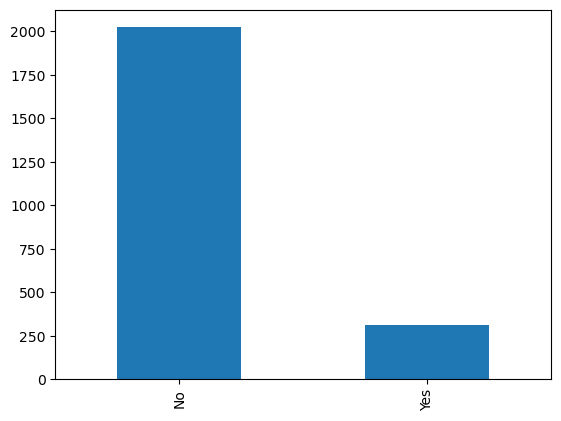

In [29]:
df[Q[1][0]].value_counts().plot.bar()

In [30]:
df[Q[1][0]].isnull().sum()

89

In [31]:
df[Q[1][0]].isnull().sum() / df.shape[0] * 100 

3.6716171617161715

In [32]:
df[Q[1][0]]=df[Q[1][0]].fillna(df[Q[1][0]].mode()[0])

### 6 - clean ` gender` column 
> tip : you should choose which best value to put in place of these NaNs ( mode, unknown,other ....etc)

In [33]:
df[Q[2][0]].value_counts()

Male                  1458
Female                 838
I'd rather not say      81
Other                   30
Name: Q2: GENDER, dtype: int64

<Axes: >

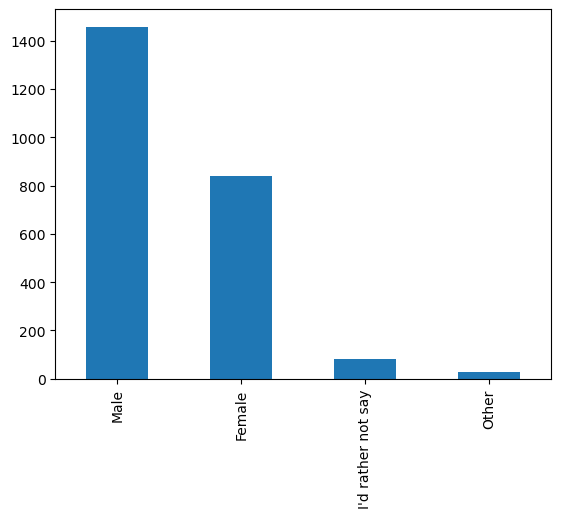

In [34]:
df[Q[2][0]].value_counts().plot.bar()

In [35]:
df[Q[2][0]].isnull().sum()

17

In [36]:
df[Q[2][0]].isnull().sum()/ df.shape[0]

0.007013201320132013

In [37]:
df[Q[2][0]].fillna("I'd rather not say" , inplace = True )

In [38]:
assert df[Q[2][0]].isnull().sum()  == 0 

### 7 - clean ` age` column 
> tip : note the type of age column , and NaN values
 - try to use `to_numeric` 
 - tip : you should choose which best value to put in place of these NaNs ( mean, median, ....etc)

In [39]:
df[Q[3][0]].unique()

array([44, 49, 40, 23, nan, 53, 33, 43, 56, 64, 37, 59, 48, 54, 36, 45,
       25, 34, 35, 38, 58, 50, 47, 16, 52, 63, 65, 41, 27, 31, 61, 46, 42,
       62, 29, 39, 32, 28, 69, 67, 30, 22, 26, 51, 70, 24, 18, 19,
       'Old enough', 57, 60, 66, 12, 'Many', 55, 72, '?', 21, 11, 'no', 9,
       68, 20, 6, 10, 71, 90, 13, '45-55', 312, 99, 7, 'hahahahaha', 88,
       39.4, 74, 102, 'older than dirt', 17, 15, 8, 75, '5u', 'Enough',
       'See question 2', '24-50', 14, 'Over 50', 100, 76, 1000,
       'sixty-nine', '46 Halloweens.', 'ancient', 77, 'OLD', 'old', 73,
       70.5, 1, 'MY NAME JEFF', 4, '59 on the day after Halloween',
       'old enough', 'your mom',
       'I can remember when Java was a cool new language', '60+'],
      dtype=object)

In [40]:
df[Q[3][0]]= pd.to_numeric(df[Q[3][0]], errors='coerce')
df[Q[3][0]]

1       44.0
2       49.0
3       40.0
4       23.0
5        NaN
        ... 
2455    24.0
2456    33.0
2457    26.0
2458    58.0
2459    66.0
Name: Q3: AGE, Length: 2424, dtype: float64

In [41]:
df[Q[3][0]].isnull().sum()

78

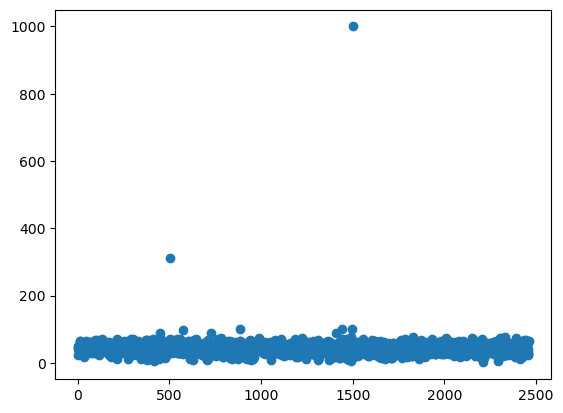

In [42]:
plt.scatter(df[Q[3][0]].index, df[Q[3][0]].values)

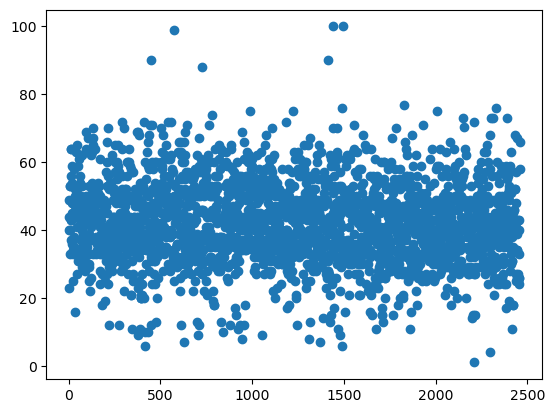

In [43]:
df[Q[3][0]] =df[Q[3][0]].apply(lambda s : np.nan if(s > 100) else s)


plt.scatter(df[Q[3][0]].index, df[Q[3][0]].values)

In [44]:
df[Q[3][0]].fillna(df[Q[3][0]].mean() , inplace=True)

In [45]:
assert df[Q[3][0]].isnull().sum() == 0

### 8 - clean `country` column

In [46]:
df[Q[4][0]].unique()

array(['USA ', 'USA', 'us', 'usa', nan, 'canada', 'Canada', 'Us', 'US',
       'Murica', 'United States', 'uk', 'United Kingdom', 'united states',
       'Usa', 'United States ', 'United staes',
       'United States of America', 'UAE', 'England', 'UK', 'canada ',
       'Mexico', 'United states', 'u.s.a.', 'USAUSAUSA', 'america', 35,
       'france', 'United States of America ', 'U.S.A.', 'finland',
       'unhinged states', 'Canada ', 'united states of america',
       'US of A', 'Unites States', 'The United States', 'North Carolina ',
       'Unied States', 'Netherlands', 'germany', 'Europe', 'Earth', 'U S',
       'u.s.', 'U.K. ', 'Costa Rica', 'The United States of America',
       'unite states', 'U.S.', 46, 'cascadia', 'Australia',
       'insanity lately', 'Greece', 'USA? Hard to tell anymore..',
       "'merica", 'usas', 'Pittsburgh', 45, 'United State', 32, 'France',
       'australia', 'A', 'Can', 'Canae', 'New York', 'Trumpistan',
       'Ireland', 'United Sates', 'Korea', 

In [47]:
matches = process.extract('united states',df[Q[4][0]],limit= df.shape[0])
matches

[('United States', 100, 18),
 ('United States', 100, 19),
 ('United States', 100, 22),
 ('United States', 100, 23),
 ('United States', 100, 24),
 ('united states', 100, 26),
 ('United States', 100, 28),
 ('United States', 100, 30),
 ('United States ', 100, 35),
 ('United States', 100, 37),
 ('United States', 100, 39),
 ('United States', 100, 40),
 ('United States', 100, 49),
 ('United States', 100, 51),
 ('United States', 100, 52),
 ('United States', 100, 54),
 ('United States', 100, 55),
 ('United States ', 100, 73),
 ('United States', 100, 75),
 ('United States', 100, 76),
 ('United States', 100, 80),
 ('United States', 100, 85),
 ('United States', 100, 87),
 ('United States', 100, 88),
 ('United States', 100, 91),
 ('United States', 100, 95),
 ('United States', 100, 101),
 ('United States', 100, 109),
 ('United States', 100, 115),
 ('United states', 100, 123),
 ('United States', 100, 124),
 ('United States ', 100, 125),
 ('United states', 100, 130),
 ('United States', 100, 132),
 ('

In [48]:
for match in matches:
  if match[1] > 60:
    df.loc[match[2],[Q[4][0]]] = "USA"

In [49]:
print(df[Q[4][0]].unique())

['USA ' 'USA' 'us' 'usa' nan 'canada' 'Canada' 'Us' 'US' 'Murica' 'uk'
 'United Kingdom' 'Usa' 'UAE' 'England' 'UK' 'canada ' 'Mexico' 'u.s.a.'
 'USAUSAUSA' 'america' 35 'france' 'U.S.A.' 'finland' 'Canada ' 'US of A'
 'North Carolina ' 'Netherlands' 'germany' 'Europe' 'Earth' 'U.K. '
 'Costa Rica' 46 'cascadia' 'Australia' 'insanity lately' 'Greece'
 'USA? Hard to tell anymore..' "'merica" 'usas' 'Pittsburgh' 45 32
 'France' 'australia' 'A' 'Can' 'Canae' 'New York' 'Trumpistan' 'Ireland'
 'Korea' 'California' 'Japan' 'USa' 'South africa' 'Usa ' 'Uk' 'Iceland'
 'Germany' 'Canada`' 'Scotland' 'UK ' 'Denmark' 'France ' 'Switzerland'
 'Ahem....Amerca' 'UD' 'Scotland ' 'South Korea' 'New Jersey' 'CANADA'
 'Indonesia' 'America' 'The Netherlands' 'endland' 'Atlantis' 'murrika'
 'USA! USA! USA!' 'USAA' 'Alaska' 'soviet canuckistan' 'N. America'
 'Singapore' 'USSA' 'China' 'Taiwan' 'Ireland ' 'hong kong' 'spain'
 'Sweden' 'Hong Kong' 'Narnia' 'u s a' 1 'subscribe to dm4uz3 on youtube'
 'United

In [50]:
matches = process.extract('canada',df[Q[4][0]],limit= df.shape[0])
matches

[('canada', 100, 7),
 ('Canada', 100, 8),
 ('Canada', 100, 11),
 ('Canada', 100, 14),
 ('Canada', 100, 21),
 ('Canada', 100, 58),
 ('Canada', 100, 61),
 ('Canada', 100, 72),
 ('Canada', 100, 77),
 ('Canada', 100, 89),
 ('canada', 100, 92),
 ('Canada', 100, 103),
 ('canada ', 100, 110),
 ('Canada', 100, 118),
 ('Canada', 100, 138),
 ('Canada', 100, 169),
 ('canada', 100, 185),
 ('Canada', 100, 226),
 ('Canada', 100, 228),
 ('canada', 100, 237),
 ('Canada', 100, 244),
 ('Canada ', 100, 262),
 ('Canada', 100, 276),
 ('Canada', 100, 285),
 ('Canada', 100, 306),
 ('canada', 100, 312),
 ('Canada', 100, 314),
 ('Canada', 100, 319),
 ('Canada', 100, 325),
 ('Canada', 100, 342),
 ('canada', 100, 351),
 ('Canada', 100, 373),
 ('Canada', 100, 374),
 ('Canada', 100, 400),
 ('Canada', 100, 408),
 ('Canada', 100, 415),
 ('Canada', 100, 429),
 ('Canada', 100, 430),
 ('Canada', 100, 447),
 ('Canada', 100, 466),
 ('canada', 100, 473),
 ('Canada', 100, 480),
 ('Canada', 100, 506),
 ('Canada', 100, 525),

In [51]:
for match in matches:
  if match[1] >70:
    df.loc[match[2],[Q[4][0]]] = "Canada"

In [52]:
df[Q[4][0]].unique()

array(['USA ', 'USA', 'us', 'usa', nan, 'Canada', 'Us', 'US', 'Murica',
       'uk', 'United Kingdom', 'Usa', 'UAE', 'England', 'UK', 'Mexico',
       'u.s.a.', 'USAUSAUSA', 'america', 35, 'france', 'U.S.A.',
       'finland', 'US of A', 'North Carolina ', 'Netherlands', 'germany',
       'Europe', 'Earth', 'U.K. ', 'Costa Rica', 46, 'Australia',
       'insanity lately', 'Greece', 'USA? Hard to tell anymore..',
       "'merica", 'usas', 'Pittsburgh', 45, 32, 'France', 'australia',
       'New York', 'Trumpistan', 'Ireland', 'Korea', 'California',
       'Japan', 'USa', 'South africa', 'Usa ', 'Uk', 'Iceland', 'Germany',
       'Scotland', 'UK ', 'Denmark', 'France ', 'Switzerland',
       'Ahem....Amerca', 'UD', 'Scotland ', 'South Korea', 'New Jersey',
       'Indonesia', 'America', 'The Netherlands', 'endland', 'Atlantis',
       'murrika', 'USA! USA! USA!', 'USAA', 'Alaska',
       'soviet canuckistan', 'N. America', 'Singapore', 'USSA', 'China',
       'Taiwan', 'Ireland ', 'hong 

In [53]:
matches = process.extract('Usa',df[Q[4][0]],limit= df.shape[0])
matches

[('USA ', 100, 1),
 ('USA', 100, 2),
 ('usa', 100, 4),
 ('usa', 100, 6),
 ('USA', 100, 15),
 ('USA', 100, 16),
 ('USA', 100, 18),
 ('USA', 100, 19),
 ('USA', 100, 22),
 ('USA', 100, 23),
 ('USA', 100, 24),
 ('USA', 100, 26),
 ('USA', 100, 27),
 ('USA', 100, 28),
 ('USA', 100, 29),
 ('USA', 100, 30),
 ('USA', 100, 31),
 ('USA', 100, 32),
 ('Usa', 100, 33),
 ('USA', 100, 34),
 ('USA', 100, 35),
 ('USA', 100, 37),
 ('Usa', 100, 38),
 ('USA', 100, 39),
 ('USA', 100, 40),
 ('USA', 100, 41),
 ('usa', 100, 45),
 ('USA', 100, 46),
 ('USA', 100, 47),
 ('Usa', 100, 48),
 ('USA', 100, 49),
 ('USA', 100, 50),
 ('USA', 100, 51),
 ('USA', 100, 52),
 ('USA', 100, 54),
 ('USA', 100, 55),
 ('USA', 100, 56),
 ('usa', 100, 57),
 ('USA', 100, 60),
 ('USA', 100, 62),
 ('USA ', 100, 63),
 ('USA', 100, 64),
 ('USA', 100, 65),
 ('Usa', 100, 66),
 ('USA', 100, 67),
 ('USA', 100, 68),
 ('USA', 100, 69),
 ('USA', 100, 70),
 ('USA', 100, 71),
 ('USA', 100, 73),
 ('USA', 100, 74),
 ('USA', 100, 75),
 ('USA', 100, 

In [54]:
matches = process.extract('us',df[Q[4][0]],limit= df.shape[0])
matches

[('us', 100, 3),
 ('Us', 100, 9),
 ('US', 100, 12),
 ('US', 100, 17),
 ('US', 100, 44),
 ('US', 100, 53),
 ('US', 100, 99),
 ('US', 100, 102),
 ('us', 100, 105),
 ('US', 100, 106),
 ('US', 100, 120),
 ('us', 100, 129),
 ('US', 100, 143),
 ('US', 100, 154),
 ('US', 100, 166),
 ('US', 100, 175),
 ('US', 100, 230),
 ('US', 100, 233),
 ('Us', 100, 236),
 ('US', 100, 278),
 ('US', 100, 279),
 ('US', 100, 293),
 ('US', 100, 298),
 ('US', 100, 303),
 ('us', 100, 304),
 ('US', 100, 307),
 ('US', 100, 308),
 ('US', 100, 328),
 ('US', 100, 329),
 ('us', 100, 355),
 ('us', 100, 387),
 ('US', 100, 390),
 ('US', 100, 404),
 ('US', 100, 432),
 ('US', 100, 434),
 ('Us', 100, 443),
 ('us', 100, 446),
 ('US', 100, 448),
 ('US', 100, 482),
 ('US', 100, 488),
 ('US', 100, 492),
 ('us', 100, 499),
 ('us', 100, 502),
 ('US', 100, 522),
 ('US', 100, 543),
 ('US', 100, 549),
 ('US', 100, 556),
 ('US', 100, 575),
 ('us', 100, 588),
 ('us', 100, 590),
 ('US', 100, 615),
 ('US', 100, 628),
 ('US', 100, 634),
 (

In [55]:
for match in matches:
  if match[1] >= 90:
    df.loc[match[2],[Q[4][0]]] = "USA"

In [56]:
df[Q[4][0]].unique()

array(['USA', nan, 'Canada', 'Murica', 'uk', 'United Kingdom', 'UAE',
       'England', 'UK', 'Mexico', 'u.s.a.', 'america', 35, 'france',
       'U.S.A.', 'finland', 'North Carolina ', 'Netherlands', 'germany',
       'Europe', 'Earth', 'U.K. ', 'Costa Rica', 46, 'insanity lately',
       'Greece', 'USA? Hard to tell anymore..', "'merica", 'Pittsburgh',
       45, 32, 'France', 'New York', 'Trumpistan', 'Ireland', 'Korea',
       'California', 'Japan', 'South africa', 'Uk', 'Iceland', 'Germany',
       'Scotland', 'UK ', 'Denmark', 'France ', 'Switzerland',
       'Ahem....Amerca', 'UD', 'Scotland ', 'South Korea', 'New Jersey',
       'Indonesia', 'America', 'The Netherlands', 'endland', 'Atlantis',
       'murrika', 'Alaska', 'soviet canuckistan', 'N. America',
       'Singapore', 'China', 'Taiwan', 'Ireland ', 'hong kong', 'spain',
       'Sweden', 'Hong Kong', 'Narnia', 'u s a', 1,
       'subscribe to dm4uz3 on youtube', 'United kingdom',
       "I don't know anymore", 'Fear and 

In [57]:
matches = process.extract('uk',df[Q[4][0]],limit= df.shape[0])
matches

[('uk', 100, 20),
 ('UK', 100, 86),
 ('UK', 100, 235),
 ('UK', 100, 322),
 ('uk', 100, 345),
 ('UK', 100, 377),
 ('UK', 100, 591),
 ('UK', 100, 610),
 ('UK', 100, 752),
 ('Uk', 100, 1184),
 ('UK', 100, 1195),
 ('UK ', 100, 1216),
 ('Uk', 100, 1242),
 ('UK', 100, 1257),
 ('UK', 100, 1325),
 ('UK', 100, 1891),
 ('UK', 100, 1905),
 ('UK', 100, 2080),
 ('U.K. ', 80, 521),
 ('u.s.a.', 57, 135),
 ('U.S.A.', 57, 224),
 ('U.S.A.', 57, 392),
 ('U.S.A.', 57, 1051),
 ('U.S.A.', 57, 1069),
 ('U.S.A.', 57, 1707),
 ('u s a', 57, 2093),
 ('U.S.A.', 57, 2297),
 ('U.S.A.', 57, 2305),
 ('UD', 50, 1267),
 ('USA', 45, 1),
 ('USA', 45, 2),
 ('USA', 45, 3),
 ('USA', 45, 4),
 ('USA', 45, 6),
 ('USA', 45, 9),
 ('USA', 45, 12),
 ('Murica', 45, 13),
 ('USA', 45, 15),
 ('USA', 45, 16),
 ('USA', 45, 17),
 ('USA', 45, 18),
 ('USA', 45, 19),
 ('USA', 45, 22),
 ('USA', 45, 23),
 ('USA', 45, 24),
 ('United Kingdom', 45, 25),
 ('USA', 45, 26),
 ('USA', 45, 27),
 ('USA', 45, 28),
 ('USA', 45, 29),
 ('USA', 45, 30),
 ('

In [58]:
for match in matches:
  if match[1] >= 80:
    df.loc[match[2],[Q[4][0]]] = "Uk"

In [59]:
df[Q[4][0]].unique()

array(['USA', nan, 'Canada', 'Murica', 'Uk', 'United Kingdom', 'UAE',
       'England', 'Mexico', 'u.s.a.', 'america', 35, 'france', 'U.S.A.',
       'finland', 'North Carolina ', 'Netherlands', 'germany', 'Europe',
       'Earth', 'Costa Rica', 46, 'insanity lately', 'Greece',
       'USA? Hard to tell anymore..', "'merica", 'Pittsburgh', 45, 32,
       'France', 'New York', 'Trumpistan', 'Ireland', 'Korea',
       'California', 'Japan', 'South africa', 'Iceland', 'Germany',
       'Scotland', 'Denmark', 'France ', 'Switzerland', 'Ahem....Amerca',
       'UD', 'Scotland ', 'South Korea', 'New Jersey', 'Indonesia',
       'America', 'The Netherlands', 'endland', 'Atlantis', 'murrika',
       'Alaska', 'soviet canuckistan', 'N. America', 'Singapore', 'China',
       'Taiwan', 'Ireland ', 'hong kong', 'spain', 'Sweden', 'Hong Kong',
       'Narnia', 'u s a', 1, 'subscribe to dm4uz3 on youtube',
       'United kingdom', "I don't know anymore", 'Fear and Loathing'],
      dtype=object)

In [60]:
matches = process.extract('United Kingdom',df[Q[4][0]],limit= df.shape[0])
matches

[('United Kingdom', 100, 25),
 ('United Kingdom', 100, 42),
 ('United Kingdom', 100, 43),
 ('United Kingdom', 100, 90),
 ('United Kingdom', 100, 465),
 ('United Kingdom', 100, 738),
 ('United Kingdom', 100, 842),
 ('United Kingdom', 100, 872),
 ('United Kingdom', 100, 873),
 ('United Kingdom', 100, 1238),
 ('United Kingdom', 100, 1577),
 ('United Kingdom', 100, 1897),
 ('United Kingdom', 100, 2198),
 ('United kingdom', 100, 2351),
 ('Indonesia', 48, 1378),
 ('Uk', 45, 20),
 ('Uk', 45, 86),
 ('Uk', 45, 235),
 ('Uk', 45, 322),
 ('Uk', 45, 345),
 ('Uk', 45, 377),
 ('Uk', 45, 521),
 ('Uk', 45, 591),
 ('Uk', 45, 610),
 ('Uk', 45, 752),
 ('New York', 45, 954),
 ('Uk', 45, 1184),
 ('Uk', 45, 1195),
 ('Uk', 45, 1216),
 ('Uk', 45, 1242),
 ('Uk', 45, 1257),
 ('UD', 45, 1267),
 ('Uk', 45, 1325),
 ('Singapore', 45, 1734),
 ('Uk', 45, 1891),
 ('Uk', 45, 1905),
 ('Sweden', 45, 1915),
 ('Uk', 45, 2080),
 ('Sweden', 45, 2188),
 ('Murica', 43, 13),
 ('hong kong', 43, 1901),
 ('Hong Kong', 43, 1976),
 (

In [61]:
for match in matches:
  if match[1] == 100:
    df.loc[match[2],[Q[4][0]]] = "Uk"

In [62]:
df[Q[4][0]].unique()

array(['USA', nan, 'Canada', 'Murica', 'Uk', 'UAE', 'England', 'Mexico',
       'u.s.a.', 'america', 35, 'france', 'U.S.A.', 'finland',
       'North Carolina ', 'Netherlands', 'germany', 'Europe', 'Earth',
       'Costa Rica', 46, 'insanity lately', 'Greece',
       'USA? Hard to tell anymore..', "'merica", 'Pittsburgh', 45, 32,
       'France', 'New York', 'Trumpistan', 'Ireland', 'Korea',
       'California', 'Japan', 'South africa', 'Iceland', 'Germany',
       'Scotland', 'Denmark', 'France ', 'Switzerland', 'Ahem....Amerca',
       'UD', 'Scotland ', 'South Korea', 'New Jersey', 'Indonesia',
       'America', 'The Netherlands', 'endland', 'Atlantis', 'murrika',
       'Alaska', 'soviet canuckistan', 'N. America', 'Singapore', 'China',
       'Taiwan', 'Ireland ', 'hong kong', 'spain', 'Sweden', 'Hong Kong',
       'Narnia', 'u s a', 1, 'subscribe to dm4uz3 on youtube',
       "I don't know anymore", 'Fear and Loathing'], dtype=object)

In [63]:
df[Q[4][0]].replace(['u.s.a.','u s a','U.S.A.'],"USA",inplace=True)

In [64]:
df[Q[4][0]].unique()

array(['USA', nan, 'Canada', 'Murica', 'Uk', 'UAE', 'England', 'Mexico',
       'america', 35, 'france', 'finland', 'North Carolina ',
       'Netherlands', 'germany', 'Europe', 'Earth', 'Costa Rica', 46,
       'insanity lately', 'Greece', 'USA? Hard to tell anymore..',
       "'merica", 'Pittsburgh', 45, 32, 'France', 'New York',
       'Trumpistan', 'Ireland', 'Korea', 'California', 'Japan',
       'South africa', 'Iceland', 'Germany', 'Scotland', 'Denmark',
       'France ', 'Switzerland', 'Ahem....Amerca', 'UD', 'Scotland ',
       'South Korea', 'New Jersey', 'Indonesia', 'America',
       'The Netherlands', 'endland', 'Atlantis', 'murrika', 'Alaska',
       'soviet canuckistan', 'N. America', 'Singapore', 'China', 'Taiwan',
       'Ireland ', 'hong kong', 'spain', 'Sweden', 'Hong Kong', 'Narnia',
       1, 'subscribe to dm4uz3 on youtube', "I don't know anymore",
       'Fear and Loathing'], dtype=object)

In [68]:
dropped = [x for x in df[Q[4][0]].unique() if isinstance(x, int) ]

In [66]:
dropped+=['subscribe to dm4uz3 on youtube', "I don't know anymore",'Fear and Loathing' , 'Ahem....Amerca' , 'Trumpistan']

In [67]:
dropped

[35,
 46,
 45,
 32,
 1,
 'subscribe to dm4uz3 on youtube',
 "I don't know anymore",
 'Fear and Loathing',
 'Ahem....Amerca',
 'Trumpistan']

In [69]:
df[Q[4][0]].replace(dropped , np.nan , inplace=True)

In [70]:
df[Q[4][0]].unique()

array(['USA', nan, 'Canada', 'Murica', 'Uk', 'UAE', 'England', 'Mexico',
       'america', 'france', 'finland', 'North Carolina ', 'Netherlands',
       'germany', 'Europe', 'Earth', 'Costa Rica', 'insanity lately',
       'Greece', 'USA? Hard to tell anymore..', "'merica", 'Pittsburgh',
       'France', 'New York', 'Trumpistan', 'Ireland', 'Korea',
       'California', 'Japan', 'South africa', 'Iceland', 'Germany',
       'Scotland', 'Denmark', 'France ', 'Switzerland', 'Ahem....Amerca',
       'UD', 'Scotland ', 'South Korea', 'New Jersey', 'Indonesia',
       'America', 'The Netherlands', 'endland', 'Atlantis', 'murrika',
       'Alaska', 'soviet canuckistan', 'N. America', 'Singapore', 'China',
       'Taiwan', 'Ireland ', 'hong kong', 'spain', 'Sweden', 'Hong Kong',
       'Narnia', 'subscribe to dm4uz3 on youtube', "I don't know anymore",
       'Fear and Loathing'], dtype=object)

In [71]:
df[Q[4][0]].value_counts()

USA                  2031
Canada                229
Uk                     33
Germany                 7
Netherlands             6
                     ... 
Iceland                 1
Murica                  1
England                 1
France                  1
Fear and Loathing       1
Name: Q4: COUNTRY, Length: 61, dtype: int64

In [72]:
df[Q[4][0]].isnull().sum()

39

In [73]:
mode = df[Q[4][0]].mode()[0]

In [74]:
df[Q[4][0]].fillna(mode , inplace=True)

In [75]:
assert df[Q[4][0]].isna().sum() == 0 

In [76]:
df[Q[4][0]] = df[Q[4][0]].astype('category')

### 9 - clean ` STATE, PROVINCE, COUNTY, ETC'` column
> tip : area column has the same problem as country columns , but looking at all it's unique values may give us another way to deal with it rather than try to fix it

In [101]:
df[Q[5][0]].nunique()

378

In [102]:
df[Q[5][0]].unique()

array(['nm', 'virginia', 'or', 'exton pa', 'california', 'colorado ',
       'ontario', 'wa', 'quebec', 'ny', 'texas', 'new york', 'co', 'in',
       'mn', 'aberdeenshire', 'alberta', 'wisconsin, 53705', 'ri', 'nc',
       'scotland', 'minnesota', 'michigan', 'florida', 'new jersey', 'va',
       'colorado', 'los angeles, california', 'ca', 'new york ',
       'chicago, illinois', 'nj', 'wisconsin', 'minnesota ', 'derbyshire',
       'london', 'illinois', 'district of columbia', 'washington',
       'massachusetts ', 'montana', 'massachusetts', 'abu dhabi', 'tx',
       'arizona', 'dc', 'yukon', 'pennsylvania ', 'md', 'ohio',
       'alberta ', 'oxfordshire', 'iowa', 'tn', 'bc', 'maryland', 'mi',
       'wisconsin ', 'alaska', 'colorado, jefferson county ', 'louisiana',
       'pa', 'co, larimer county', 'nebraska ', 'oregon', 'ut',
       'pennsylvania', 'cdmx', 'north carolina', 'tennessee ', 'texas ',
       'knox county, tennessee', 'new mexico', 'maine',
       'virginia, arlingto

In [103]:
df[Q[5][0]]= df[Q[5][0]].str.lower()

In [104]:
df[Q[5][0]].nunique()

378

In [105]:
df[Q[5][0]].isna().sum()

0

In [106]:
df[Q[5][0]].unique()

array(['nm', 'virginia', 'or', 'exton pa', 'california', 'colorado ',
       'ontario', 'wa', 'quebec', 'ny', 'texas', 'new york', 'co', 'in',
       'mn', 'aberdeenshire', 'alberta', 'wisconsin, 53705', 'ri', 'nc',
       'scotland', 'minnesota', 'michigan', 'florida', 'new jersey', 'va',
       'colorado', 'los angeles, california', 'ca', 'new york ',
       'chicago, illinois', 'nj', 'wisconsin', 'minnesota ', 'derbyshire',
       'london', 'illinois', 'district of columbia', 'washington',
       'massachusetts ', 'montana', 'massachusetts', 'abu dhabi', 'tx',
       'arizona', 'dc', 'yukon', 'pennsylvania ', 'md', 'ohio',
       'alberta ', 'oxfordshire', 'iowa', 'tn', 'bc', 'maryland', 'mi',
       'wisconsin ', 'alaska', 'colorado, jefferson county ', 'louisiana',
       'pa', 'co, larimer county', 'nebraska ', 'oregon', 'ut',
       'pennsylvania', 'cdmx', 'north carolina', 'tennessee ', 'texas ',
       'knox county, tennessee', 'new mexico', 'maine',
       'virginia, arlingto

In [83]:
counriesGState = df.groupby(df[Q[4][0]]).nunique()[Q[5][0]].sort_values(ascending=False).to_frame().head(15)
counriesGState

,"Q5: STATE, PROVINCE, COUNTY, ETC"
Q4: COUNTRY,
USA,267
Canada,35
Uk,20
Netherlands,5
Germany,5
Scotland,3
america,3
Mexico,3
Japan,3


In [84]:
counriesGState = df[Q[4]].value_counts().head(15)

In [85]:
countries = [el[0] for el in counriesGState.index]
countries

['USA',
 'Canada',
 'Uk',
 'Germany',
 'Netherlands',
 'Japan',
 'Mexico',
 'Scotland',
 'america',
 'Switzerland',
 'germany',
 'Ireland',
 'Sweden',
 'America',
 'Denmark']

In [86]:
country_most_f = {}

for c in list(countries):
    country_most_f[c] = mode_result = df.loc[df[Q[4][0]] == c, Q[5][0]].mode()[0]


In [87]:
country_most_f

{'USA': 'california',
 'Canada': 'ontario',
 'Uk': 'derbyshire',
 'Germany': 'berlin',
 'Netherlands': 'noord-brabant',
 'Japan': 'tokyo',
 'Mexico': 'mexico city',
 'Scotland': 'glasgow',
 'america': 'massachusetts',
 'Switzerland': 'vaud',
 'germany': 'hesse',
 'Ireland': 'dublin',
 'Sweden': 'skane',
 'America': 'alabama',
 'Denmark': '¯rb¾k'}

In [88]:
for c , most_freq in country_most_f.items() :
    df.loc[ (df[Q[4][0]] == c) & (df[Q[5][0]]).isnull()  , Q[5][0]]= most_freq

In [90]:
df[Q[5][0]].isna().sum()

8

In [91]:
df.dropna(subset=Q[5][0] , inplace=True)

In [92]:
assert df[Q[5][0]].isna().sum() == 0 

### 10 - clean ` Q6` columns
>- tip : Q6 has all kinds of chocolate bars and questions with three distinct options to choose from (Joy, Meh, Despair).
- so all the column that has Q6 is a candy name , so you should go through all these column and you should choose which best value to put in place of these NaNs ( mode, unknown,other ....etc)

In [93]:
df[Q[6]]

,Q6: 100 Grand Bar,Q6: Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6: Any full-sized candy bar,Q6: Black Jacks,Q6: Bonkers (the candy),Q6: Bonkers (the board game),Q6: Bottle Caps,Q6: Box'o'Raisins,Q6: Broken glow stick,Q6: Butterfinger,Q6: Cadbury Creme Eggs,Q6: Candy Corn,Q6: Candy that is clearly just the stuff given out for free at restaurants,Q6: Caramellos,"Q6: Cash, or other forms of legal tender",Q6: Chardonnay,Q6: Chick-o-Sticks (we donÕt know what that is),Q6: Chiclets,Q6: Coffee Crisp,Q6: Creepy Religious comics/Chick Tracts,Q6: Dental paraphenalia,Q6: Dots,Q6: Dove Bars,Q6: Fuzzy Peaches,Q6: Generic Brand Acetaminophen,Q6: Glow sticks,Q6: Goo Goo Clusters,Q6: Good N' Plenty,Q6: Gum from baseball cards,Q6: Gummy Bears straight up,Q6: Hard Candy,Q6: Healthy Fruit,Q6: Heath Bar,Q6: Hershey's Dark Chocolate,Q6: HersheyÕs Milk Chocolate,Q6: Hershey's Kisses,Q6: Hugs (actual physical hugs),Q6: Jolly Rancher (bad flavor),Q6: Jolly Ranchers (good flavor),Q6: JoyJoy (Mit Iodine!),Q6: Junior Mints,Q6: Senior Mints,Q6: Kale smoothie,Q6: Kinder Happy Hippo,Q6: Kit Kat,Q6: LaffyTaffy,Q6: LemonHeads,Q6: Licorice (not black),Q6: Licorice (yes black),Q6: Lindt Truffle,Q6: Lollipops,Q6: Mars,Q6: Maynards,Q6: Mike and Ike,Q6: Milk Duds,Q6: Milky Way,Q6: Regular M&Ms,Q6: Peanut M&MÕs,Q6: Blue M&M's,Q6: Red M&M's,Q6: Green Party M&M's,Q6: Independent M&M's,Q6: Abstained from M&M'ing.,Q6: Minibags of chips,Q6: Mint Kisses,Q6: Mint Juleps,Q6: Mr. Goodbar,Q6: Necco Wafers,Q6: Nerds,Q6: Nestle Crunch,Q6: Now'n'Laters,Q6: Peeps,Q6: Pencils,Q6: Pixy Stix,Q6: Real Housewives of Orange County Season 9 Blue-Ray,Q6: ReeseÕs Peanut Butter Cups,Q6: Reese's Pieces,Q6: Reggie Jackson Bar,Q6: Rolos,Q6: Sandwich-sized bags filled with BooBerry Crunch,Q6: Skittles,Q6: Smarties (American),Q6: Smarties (Commonwealth),Q6: Snickers,Q6: Sourpatch Kids (i.e. abominations of nature),Q6: Spotted Dick,Q6: Starburst,Q6: Sweet Tarts,Q6: Swedish Fish,Q6: Sweetums (a friend to diabetes),Q6: Take 5,Q6: Tic Tacs,Q6: Those odd marshmallow circus peanut things,Q6: Three Musketeers,Q6: Tolberone something or other,Q6: Trail Mix,Q6: Twix,"Q6: Vials of pure high fructose corn syrup, for main-lining into your vein",Q6: Vicodin,Q6: Whatchamacallit Bars,Q6: White Bread,Q6: Whole Wheat anything,Q6: York Peppermint Patties
1,MEH,DESPAIR,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,JOY,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,MEH,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,JOY,JOY,MEH,JOY,JOY,JOY,JOY,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MEH,DESPAIR,JOY,MEH,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,DESPAIR,MEH,JOY,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,MEH,MEH,JOY,JOY,MEH,DESPAIR,JOY,MEH,MEH,DESPAIR,MEH,MEH,MEH,MEH,MEH,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,JOY,JOY,MEH,JOY,JOY,DESPAIR,JOY,MEH,MEH,DESPAIR,JOY,MEH,JOY,MEH,MEH,MEH,MEH,MEH,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,MEH,MEH,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,MEH,MEH,MEH,DESPAIR,DESPAIR,DESPAIR,MEH,JOY,MEH,DESPAIR,MEH,MEH,JOY,MEH,JOY,MEH,DESPAIR,DESPAIR,JOY,MEH,JOY,DESPAIR,JOY,JOY,DESPAIR,DESPAIR,DESPAIR
4,JOY,DESPAIR,JOY,DESPAIR,ME

In [94]:
df[Q[6]].apply(lambda x: pd.Series(round( x.isnull().sum() / df.shape[0] *100 ,2 ) ) )

,Q6: 100 Grand Bar,Q6: Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6: Any full-sized candy bar,Q6: Black Jacks,Q6: Bonkers (the candy),Q6: Bonkers (the board game),Q6: Bottle Caps,Q6: Box'o'Raisins,Q6: Broken glow stick,Q6: Butterfinger,Q6: Cadbury Creme Eggs,Q6: Candy Corn,Q6: Candy that is clearly just the stuff given out for free at restaurants,Q6: Caramellos,"Q6: Cash, or other forms of legal tender",Q6: Chardonnay,Q6: Chick-o-Sticks (we donÕt know what that is),Q6: Chiclets,Q6: Coffee Crisp,Q6: Creepy Religious comics/Chick Tracts,Q6: Dental paraphenalia,Q6: Dots,Q6: Dove Bars,Q6: Fuzzy Peaches,Q6: Generic Brand Acetaminophen,Q6: Glow sticks,Q6: Goo Goo Clusters,Q6: Good N' Plenty,Q6: Gum from baseball cards,Q6: Gummy Bears straight up,Q6: Hard Candy,Q6: Healthy Fruit,Q6: Heath Bar,Q6: Hershey's Dark Chocolate,Q6: HersheyÕs Milk Chocolate,Q6: Hershey's Kisses,Q6: Hugs (actual physical hugs),Q6: Jolly Rancher (bad flavor),Q6: Jolly Ranchers (good flavor),Q6: JoyJoy (Mit Iodine!),Q6: Junior Mints,Q6: Senior Mints,Q6: Kale smoothie,Q6: Kinder Happy Hippo,Q6: Kit Kat,Q6: LaffyTaffy,Q6: LemonHeads,Q6: Licorice (not black),Q6: Licorice (yes black),Q6: Lindt Truffle,Q6: Lollipops,Q6: Mars,Q6: Maynards,Q6: Mike and Ike,Q6: Milk Duds,Q6: Milky Way,Q6: Regular M&Ms,Q6: Peanut M&MÕs,Q6: Blue M&M's,Q6: Red M&M's,Q6: Green Party M&M's,Q6: Independent M&M's,Q6: Abstained from M&M'ing.,Q6: Minibags of chips,Q6: Mint Kisses,Q6: Mint Juleps,Q6: Mr. Goodbar,Q6: Necco Wafers,Q6: Nerds,Q6: Nestle Crunch,Q6: Now'n'Laters,Q6: Peeps,Q6: Pencils,Q6: Pixy Stix,Q6: Real Housewives of Orange County Season 9 Blue-Ray,Q6: ReeseÕs Peanut Butter Cups,Q6: Reese's Pieces,Q6: Reggie Jackson Bar,Q6: Rolos,Q6: Sandwich-sized bags filled with BooBerry Crunch,Q6: Skittles,Q6: Smarties (American),Q6: Smarties (Commonwealth),Q6: Snickers,Q6: Sourpatch Kids (i.e. abominations of nature),Q6: Spotted Dick,Q6: Starburst,Q6: Sweet Tarts,Q6: Swedish Fish,Q6: Sweetums (a friend to diabetes),Q6: Take 5,Q6: Tic Tacs,Q6: Those odd marshmallow circus peanut things,Q6: Three Musketeers,Q6: Tolberone something or other,Q6: Trail Mix,Q6: Twix,"Q6: Vials of pure high fructose corn syrup, for main-lining into your vein",Q6: Vicodin,Q6: Whatchamacallit Bars,Q6: White Bread,Q6: Whole Wheat anything,Q6: York Peppermint Patties
0,29.3,28.77,26.2,38.04,39.45,40.02,30.05,26.86,27.61,26.61,26.66,26.45,26.99,29.51,26.53,29.14,37.54,27.81,33.69,27.52,27.03,28.56,27.44,32.45,28.64,27.24,34.77,28.77,28.02,27.24,27.15,27.11,27.86,26.24,26.2,26.45,27.9,27.11,27.15,40.85,27.28,37.38,29.18,37.5,26.28,28.85,28.6,26.78,26.74,28.1,26.99,28.39,40.77,28.56,27.07,26.86,26.32,26.16,28.48,28.56,30.01,32.04,37.38,28.35,30.46,31.95,29.01,29.18,28.31,27.28,32.2,27.77,27.73,28.27,29.55,26.45,26.95,40.31,27.9,30.5,27.61,28.39,35.68,26.95,28.93,34.89,27.07,27.65,27.98,39.78,36.3,27.94,28.85,27.69,27.61,27.61,26.9,31.17,31.04,32.45,29.72,29.3,27.57


In [96]:
df.loc[:, Q[6]] = df[Q[6]].fillna("Unknown")

### 11 - clean ` dress` column
>tip : you should choose which best value to put in place of these NaNs ( mode, unknown,other ....etc)

In [97]:
df[Q[10][0]].isnull().sum() / df.shape[0]

0.2913907284768212

<Axes: >

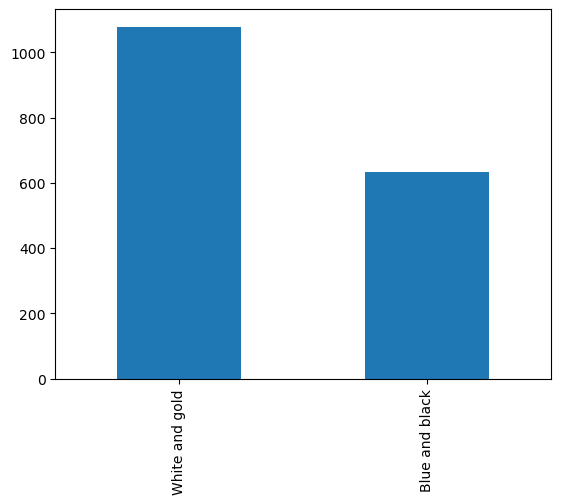

In [98]:
df[Q[10][0]].value_counts().plot.bar()

In [100]:
df[Q[10][0]].fillna( 'Unknown' , inplace= True) 

### 12 - clean ` day` column
>tip : you should choose which best value to put in place of these NaNs ( mode, unknown,other ....etc)

<Axes: >

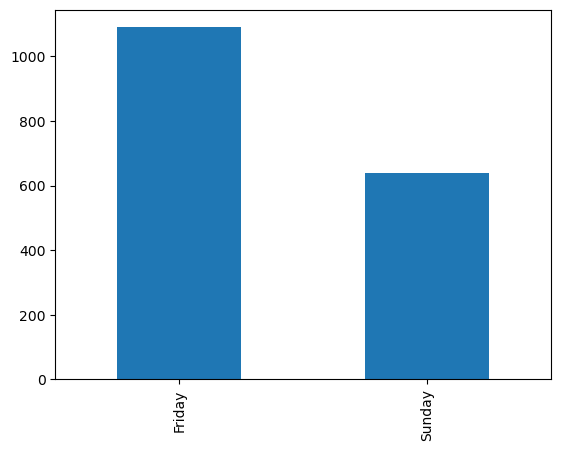

In [107]:
df[Q[11][0]].value_counts().plot.bar()

In [108]:
df[Q[11][0]].fillna( 'Other', inplace= True) 

In [109]:
assert df[Q[11][0]].isna().sum() ==0

In [110]:
df[Q[11][0]].value_counts()

Friday    1090
Other      686
Sunday     640
Name: Q11: DAY, dtype: int64

### 13 - check
> after finish cleaning you should make sure your data is clean and that :
- there is no wrong data type
- there is no NaN values 
- all the column are cleaing and ready for the next step `EDA`

In [111]:
df

,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6: 100 Grand Bar,Q6: Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6: Any full-sized candy bar,Q6: Black Jacks,Q6: Bonkers (the candy),Q6: Bonkers (the board game),Q6: Bottle Caps,Q6: Box'o'Raisins,Q6: Broken glow stick,Q6: Butterfinger,Q6: Cadbury Creme Eggs,Q6: Candy Corn,Q6: Candy that is clearly just the stuff given out for free at restaurants,Q6: Caramellos,"Q6: Cash, or other forms of legal tender",Q6: Chardonnay,Q6: Chick-o-Sticks (we donÕt know what that is),Q6: Chiclets,Q6: Coffee Crisp,Q6: Creepy Religious comics/Chick Tracts,Q6: Dental paraphenalia,Q6: Dots,Q6: Dove Bars,Q6: Fuzzy Peaches,Q6: Generic Brand Acetaminophen,Q6: Glow sticks,Q6: Goo Goo Clusters,Q6: Good N' Plenty,Q6: Gum from baseball cards,Q6: Gummy Bears straight up,Q6: Hard Candy,Q6: Healthy Fruit,Q6: Heath Bar,Q6: Hershey's Dark Chocolate,Q6: HersheyÕs Milk Chocolate,Q6: Hershey's Kisses,Q6: Hugs (actual physical hugs),Q6: Jolly Rancher (bad flavor),Q6: Jolly Ranchers (good flavor),Q6: JoyJoy (Mit Iodine!),Q6: Junior Mints,Q6: Senior Mints,Q6: Kale smoothie,Q6: Kinder Happy Hippo,Q6: Kit Kat,Q6: LaffyTaffy,Q6: LemonHeads,Q6: Licorice (not black),Q6: Licorice (yes black),Q6: Lindt Truffle,Q6: Lollipops,Q6: Mars,Q6: Maynards,Q6: Mike and Ike,Q6: Milk Duds,Q6: Milky Way,Q6: Regular M&Ms,Q6: Peanut M&MÕs,Q6: Blue M&M's,Q6: Red M&M's,Q6: Green Party M&M's,Q6: Independent M&M's,Q6: Abstained from M&M'ing.,Q6: Minibags of chips,Q6: Mint Kisses,Q6: Mint Juleps,Q6: Mr. Goodbar,Q6: Necco Wafers,Q6: Nerds,Q6: Nestle Crunch,Q6: Now'n'Laters,Q6: Peeps,Q6: Pencils,Q6: Pixy Stix,Q6: Real Housewives of Orange County Season 9 Blue-Ray,Q6: ReeseÕs Peanut Butter Cups,Q6: Reese's Pieces,Q6: Reggie Jackson Bar,Q6: Rolos,Q6: Sandwich-sized bags filled with BooBerry Crunch,Q6: Skittles,Q6: Smarties (American),Q6: Smarties (Commonwealth),Q6: Snickers,Q6: Sourpatch Kids (i.e. abominations of nature),Q6: Spotted Dick,Q6: Starburst,Q6: Sweet Tarts,Q6: Swedish Fish,Q6: Sweetums (a friend to diabetes),Q6: Take 5,Q6: Tic Tacs,Q6: Those odd marshmallow circus peanut things,Q6: Three Musketeers,Q6: Tolberone something or other,Q6: Trail Mix,Q6: Twix,"Q6: Vials of pure high fructose corn syrup, for main-lining into your vein",Q6: Vicodin,Q6: Whatchamacallit Bars,Q6: White Bread,Q6: Whole Wheat anything,Q6: York Peppermint Patties,Q10: DRESS,Q11: DAY
1,No,Male,44.00000,USA,nm,MEH,DESPAIR,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,MEH,DESPAIR,MEH,JOY,JOY,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,MEH,MEH,JOY,MEH,DESPAIR,DESPAIR,DESPAIR,MEH,MEH,JOY,JOY,MEH,JOY,JOY,JOY,JOY,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,MEH,DESPAIR,DESPAIR,MEH,DESPAIR,MEH,DESPAIR,DESPAIR,DESPAIR,DESPAIR,JOY,JOY,DESPAIR,JOY,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,DESPAIR,White and gold,Sunday
2,No,Male,49.00000,USA,virginia,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unkno

In [112]:
df.isnull().sum().to_frame().T

,Q1: GOING OUT?,Q2: GENDER,Q3: AGE,Q4: COUNTRY,"Q5: STATE, PROVINCE, COUNTY, ETC",Q6: 100 Grand Bar,Q6: Anonymous brown globs that come in black and orange wrappers\t(a.k.a. Mary Janes),Q6: Any full-sized candy bar,Q6: Black Jacks,Q6: Bonkers (the candy),Q6: Bonkers (the board game),Q6: Bottle Caps,Q6: Box'o'Raisins,Q6: Broken glow stick,Q6: Butterfinger,Q6: Cadbury Creme Eggs,Q6: Candy Corn,Q6: Candy that is clearly just the stuff given out for free at restaurants,Q6: Caramellos,"Q6: Cash, or other forms of legal tender",Q6: Chardonnay,Q6: Chick-o-Sticks (we donÕt know what that is),Q6: Chiclets,Q6: Coffee Crisp,Q6: Creepy Religious comics/Chick Tracts,Q6: Dental paraphenalia,Q6: Dots,Q6: Dove Bars,Q6: Fuzzy Peaches,Q6: Generic Brand Acetaminophen,Q6: Glow sticks,Q6: Goo Goo Clusters,Q6: Good N' Plenty,Q6: Gum from baseball cards,Q6: Gummy Bears straight up,Q6: Hard Candy,Q6: Healthy Fruit,Q6: Heath Bar,Q6: Hershey's Dark Chocolate,Q6: HersheyÕs Milk Chocolate,Q6: Hershey's Kisses,Q6: Hugs (actual physical hugs),Q6: Jolly Rancher (bad flavor),Q6: Jolly Ranchers (good flavor),Q6: JoyJoy (Mit Iodine!),Q6: Junior Mints,Q6: Senior Mints,Q6: Kale smoothie,Q6: Kinder Happy Hippo,Q6: Kit Kat,Q6: LaffyTaffy,Q6: LemonHeads,Q6: Licorice (not black),Q6: Licorice (yes black),Q6: Lindt Truffle,Q6: Lollipops,Q6: Mars,Q6: Maynards,Q6: Mike and Ike,Q6: Milk Duds,Q6: Milky Way,Q6: Regular M&Ms,Q6: Peanut M&MÕs,Q6: Blue M&M's,Q6: Red M&M's,Q6: Green Party M&M's,Q6: Independent M&M's,Q6: Abstained from M&M'ing.,Q6: Minibags of chips,Q6: Mint Kisses,Q6: Mint Juleps,Q6: Mr. Goodbar,Q6: Necco Wafers,Q6: Nerds,Q6: Nestle Crunch,Q6: Now'n'Laters,Q6: Peeps,Q6: Pencils,Q6: Pixy Stix,Q6: Real Housewives of Orange County Season 9 Blue-Ray,Q6: ReeseÕs Peanut Butter Cups,Q6: Reese's Pieces,Q6: Reggie Jackson Bar,Q6: Rolos,Q6: Sandwich-sized bags filled with BooBerry Crunch,Q6: Skittles,Q6: Smarties (American),Q6: Smarties (Commonwealth),Q6: Snickers,Q6: Sourpatch Kids (i.e. abominations of nature),Q6: Spotted Dick,Q6: Starburst,Q6: Sweet Tarts,Q6: Swedish Fish,Q6: Sweetums (a friend to diabetes),Q6: Take 5,Q6: Tic Tacs,Q6: Those odd marshmallow circus peanut things,Q6: Three Musketeers,Q6: Tolberone something or other,Q6: Trail Mix,Q6: Twix,"Q6: Vials of pure high fructose corn syrup, for main-lining into your vein",Q6: Vicodin,Q6: Whatchamacallit Bars,Q6: White Bread,Q6: Whole Wheat anything,Q6: York Peppermint Patties,Q10: DRESS,Q11: DAY
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [113]:
df.to_csv("Cleaning_Data1.csv")